In [ ]:
#libraries and data path
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import emoji 
from wordcloud import WordCloud

# NLTK download
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# visualization setting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# data path
DATA_PATH = 'cyberbullying_tweets.csv'
print("✅ The libraries have been installed and configured..")

✅ Kütüphaneler yüklendi ve ayarlar yapıldı.


In [ ]:
# Dictionary
# --- 1. Emoticons - ---
emoticon_dict = {
    ":)": " smile ", ":-)": " smile ", ":D": " laugh ", ":-D": " laugh ", "XD": " laugh ",
    ":(": " sad ", ":-(": " sad ", ":'(": " cry ", ":/": " skeptical ", ":\\": " skeptical ",
    ";)": " wink ", ";-)": " wink ", "^_^": " happy ",
    ":P": " playful ", ":-P": " playful ", ":p": " playful ",
    "<3": " love ", "♥": " love ", "</3": " heartbreak ",
    ":O": " surprise ", ":-O": " surprise ",
    ">:)": " evil ", ">:(": " angry ", ":@": " angry ",
    "-_-": " annoyed ", "-.-": " annoyed "
}

# --- 2.  (Slang -  ---
slang_dict = {
    
    "u": "you", "ur": "your", "urs": "yours", 
    "r": "are", "b": "be", 
    "n": "and", "w": "with", "w/o": "without",
    "dm": "direct message", "rt": "retweet",
    
    
    "lol": "laughing out loud", "lmao": "laughing my ass off", "rofl": "rolling on the floor laughing",
    "omg": "oh my god", "omfg": "oh my fucking god",
    "wtf": "what the fuck", "wth": "what the hell",
    "idk": "i do not know", "idek": "i do not even know",
    "smh": "shaking my head",
    "tbh": "to be honest", "imo": "in my opinion", "imho": "in my humble opinion",
    "btw": "by the way", "fyi": "for your information",
    "jk": "just kidding", "thx": "thanks", "pls": "please", "plz": "please",
    
    
    "kys": "kill yourself", 
    "stfu": "shut the fuck up", "gtfo": "get the fuck out",
    "f": "fuck", "fu": "fuck you", "f u": "fuck you",
    "sob": "son of a bitch", "bs": "bullshit",
    "mf": "motherfucker", "af": "as fuck",
    "die": "die", "ugly": "ugly", "idiot": "idiot", 
    
    
    "im": "i am", "ive": "i have", "ill": "i will", "id": "i would",
    "dont": "do not", "doesnt": "does not", "didnt": "did not",
    "cant": "cannot", "wont": "will not", "wouldnt": "would not", "couldnt": "could not",
    "shouldnt": "should not", "havent": "have not", "hasnt": "has not",
    "aint": "is not", "wanna": "want to", "gonna": "going to", "gotta": "got to",
    "lemme": "let me", "kinda": "kind of", "sorta": "sort of",
    "bc": "because", "cos": "because", "cuz": "because"
}

# --- 3.Leetspeak / Obfuscation ---
censorship_map = {
    "0": "o", 
    "1": "i", "!": "i", 
    "@": "a", "4": "a", 
    "$": "s", "5": "s", "z": "s",
    "3": "e", 
    "7": "t", "+": "t",
    "*": "u" # f*ck -> fuck
}

# --- 4. Turkish  ---
tr_map = {
    'ğ': 'g', 'ü': 'u', 'ş': 's', 'ı': 'i', 'ö': 'o', 'ç': 'c',
    'Ğ': 'g', 'Ü': 'u', 'Ş': 's', 'İ': 'i', 'Ö': 'o', 'Ç': 'c'
}



In [ ]:

def clean_text(text):
    if not isinstance(text, str):
        return ""
    
   
    text = text.replace('&amp;', '') 
    text = text.replace('&lt;', '')
    text = text.replace('&gt;', '')
    
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'^RT[\s]+', '', text)
    
    
    # #ImACelebrity -> Im A Celebrity
    text = text.replace('#', ' ') 
    text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text) # camelCase
    text = re.sub(r'([A-Z])([A-Z][a-z])', r'\1 \2', text) # PascalCase/Acronyms

    # emoji -> text
    for emot, meaning in emoticon_dict.items():
        text = text.replace(emot, meaning)
    text = emoji.demojize(text, delimiters=(" ", " ")) 

    # lowercase
    text = text.lower()
    
    text = re.sub(r"imnot", "i am not", text)
    text = re.sub(r"iamnot", "i am not", text)
    text = re.sub(r"isnot", "is not", text)
    text = re.sub(r"arenot", "are not", text)
    text = re.sub(r"cannot", "can not", text)

    text = re.sub(r"n\'t", " not", text)  # don't -> do not
    text = re.sub(r"\'m", " am", text)    # I'm -> I am
    text = re.sub(r"\'re", " are", text)  # you're -> you are
    text = re.sub(r"\'s", " is", text)    # it's -> it is
    text = re.sub(r"\'d", " would", text) # I'd -> I would
    text = re.sub(r"\'ll", " will", text) # I'll -> I will
    text = re.sub(r"\'ve", " have", text) # I've -> I have
    
    # classss -> class
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # ğ -> g 
    for tr_char, en_char in tr_map.items():
        text = text.replace(tr_char, en_char)

    #  remove dots and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Kelime Kelime İşleme (Argo ve Sansür)
    words = text.split()
    cleaned_words = []
    
    for word in words:
        # A. Sansür Düzeltme
        for key, val in censorship_map.items():
            if key in word:
                word = word.replace(key, val)
        
        # B. Argo Açılımı
        if word in slang_dict:
            word = slang_dict[word]
            
        cleaned_words.append(word)
    
    text = " ".join(cleaned_words)

    # Stopwords (Önemli Kelimeler KORUNUYOR)
    stop_words = set(stopwords.words('english'))
    
    stop_words.update({'wa', 'amp', 'wan', 'na'})
    keep_words = {
        'no', 'not', 'nor', 'neither', 'never', 'none', "don't", "aren't", "couldn't", "cannot", 
        "why", "what", "how", "who", "where", "when", 
        "i", "you", "he", "she", "it", "we", "they", "me", "my", "your", 
        "am", "is", "are",  "were", "be", "im"
    }
    stop_words = stop_words - keep_words
    
    lemmatizer = WordNetLemmatizer()
    final_words = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words and len(word) > 1]
    
    return " ".join(final_words)

print("✅ Temizlik fonksiyonu hazır.")

✅ Temizlik fonksiyonu hazır.


In [ ]:
#data loading
try:
    df = pd.read_csv(DATA_PATH)
    print(f"📂 Data set loaded: {df.shape[0]} line.")
except FileNotFoundError:
    print("❌ ERROR: File not found. Please check the file path.")

# Apply Cleaning
print("⏳ Cleaning process has started (Please wait)...")

df['cleaned_text'] = df['tweet_text'].apply(clean_text)

print("✅ The cleaning is complete! Here are the first 5 examples:")
pd.set_option('display.max_colwidth', None)
display(df[['tweet_text', 'cleaned_text']].head())

output_filename = 'cyberbullying_tweets_CLEANED.csv'
df.to_csv(output_filename, index=False)

print(f"\n💾 OPERATION SUCCESSFUL! Data cleared. '{output_filename}' saved under the name.")
print("We can now train machine learning models using this new file..")

📂 Veri seti yüklendi: 47692 satır.
⏳ Temizlik işlemi başlatıldı (Lütfen bekleyin)...
✅ Temizlik tamamlandı! İşte ilk 5 örnek:


,tweet_text,cleaned_text
0,"In other words #katandandre, your food was crapilicious! #mkr",word katandandre your food crapilicious mkr
1,Why is #aussietv so white? #MKR #theblock #ImACelebrityAU #today #sunrise #studio10 #Neighbours #WonderlandTen #etc,why is aussietv white mkr theblock am celebrity au today sunrise studio neighbour wonderland ten etc
2,@XochitlSuckkks a classy whore? Or more red velvet cupcakes?,classy whore red velvet cupcake
3,"@Jason_Gio meh. :P thanks for the heads up, but not too concerned about another angry dude on twitter.",meh playful thanks head not concerned another angry dude twitter
4,"@RudhoeEnglish This is an ISIS account pretending to be a Kurdish account. Like Islam, it is all lies.",is isi account pretending be kurdish account like islam it is lie



💾 İŞLEM BAŞARILI! Temizlenmiş veri 'cyberbullying_tweets_CLEANED.csv' adıyla kaydedildi.
Artık makine öğrenmesi modellerini bu yeni dosya üzerinden eğitebiliriz.


📊 Veri Görselleştirme Hazırlanıyor...


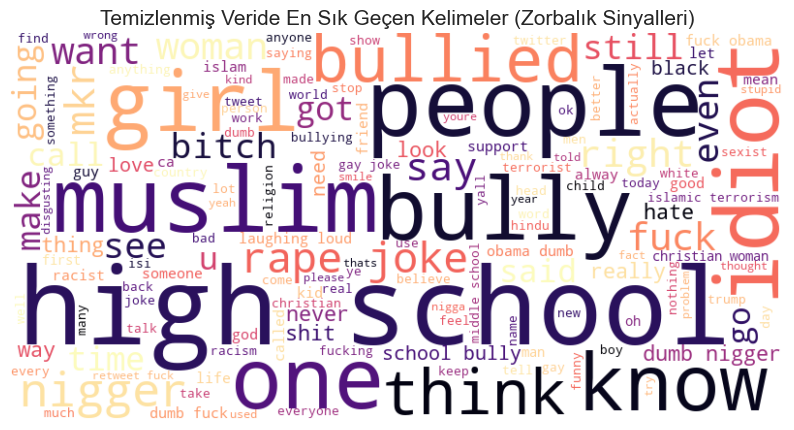

C:\Users\user\AppData\Local\Temp\ipykernel_29188\67830299.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='cyberbullying_type', data=df, palette='viridis',


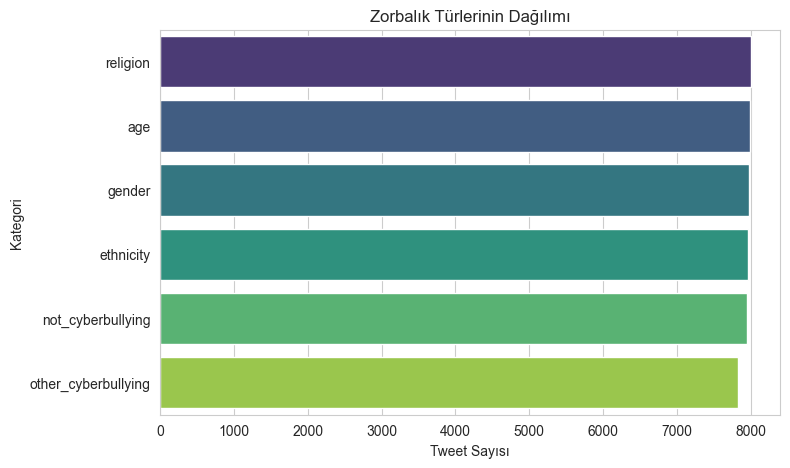

✅ İnceleme ipucu: Kelime bulutunda 'nigger', 'dumb', 'school', 'joke' gibi kelimeler görüyorsan temizlik başarılıdır.


In [ ]:
# --- visualization ---
from wordcloud import WordCloud

print(" Data visualization is being prepared...")

# WordCloud
# Tüm temizlenmiş metni tek bir string yap
all_words = " ".join(df['cleaned_text'])


wordcloud = WordCloud(width=800, height=400, 
                    background_color='white', 
                    colormap='magma', 
                    min_font_size=10).generate(all_words)


plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in the Cleaned Data (Bullying Signals)', fontsize=15)
plt.show()


plt.figure(figsize=(8, 5))
sns.countplot(y='cyberbullying_type', data=df, palette='viridis', 
              order=df['cyberbullying_type'].value_counts().index)
plt.title('Distribution of Bullying Types')
plt.xlabel('Number of Tweets')
plt.ylabel('Category')
plt.show()



🚀 70-15-15 SPLIT VE ÇİFT MODEL TESTİ BAŞLIYOR...
📦 Veri Dağılımı: Train=33384 | Val=7154 | Test=7154

🔢 Kelimeler sayılara dökülüyor...

🏁 YARIŞ BAŞLADI! İki model de teste giriyor...

🤖 MODEL: Logistic Regression
   🔹 Validation (Ara Sınav) Başarısı: %82.93
   🏆 TEST (Final) Başarısı: %82.11
------------------------------

📄 Logistic Regression İçin Sınıflandırma Raporu:

                     precision    recall  f1-score   support

                age       0.95      0.97      0.96      1199
          ethnicity       0.97      0.97      0.97      1194
             gender       0.90      0.83      0.86      1196
  not_cyberbullying       0.60      0.49      0.54      1192
other_cyberbullying       0.57      0.72      0.64      1174
           religion       0.95      0.94      0.95      1199

           accuracy                           0.82      7154
          macro avg       0.83      0.82      0.82      7154
       weighted avg       0.83      0.82      0.82      7154



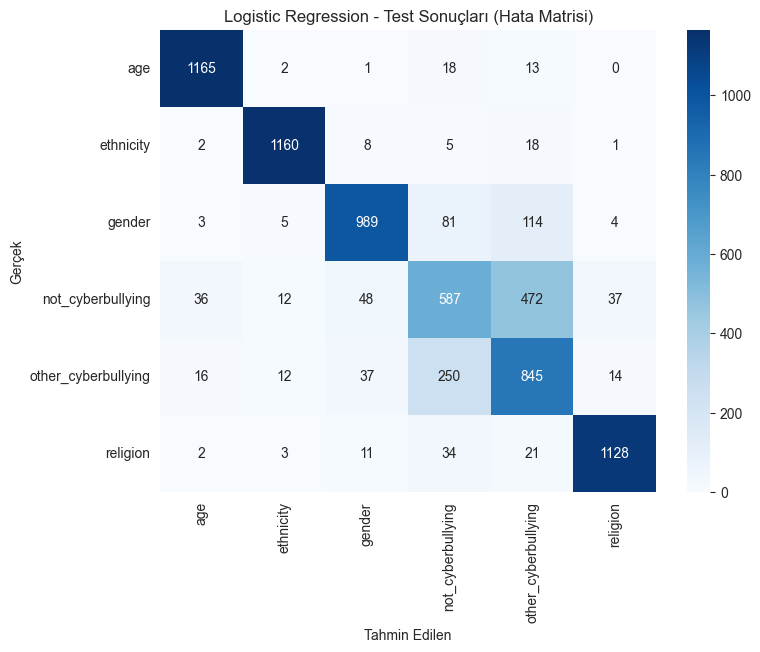




🤖 MODEL: SVM (Linear SVC)
   🔹 Validation (Ara Sınav) Başarısı: %82.29
   🏆 TEST (Final) Başarısı: %81.41
------------------------------

📄 SVM (Linear SVC) İçin Sınıflandırma Raporu:

                     precision    recall  f1-score   support

                age       0.95      0.97      0.96      1199
          ethnicity       0.97      0.97      0.97      1194
             gender       0.88      0.84      0.86      1196
  not_cyberbullying       0.57      0.49      0.53      1192
other_cyberbullying       0.56      0.66      0.61      1174
           religion       0.95      0.94      0.95      1199

           accuracy                           0.81      7154
          macro avg       0.82      0.81      0.81      7154
       weighted avg       0.82      0.81      0.81      7154



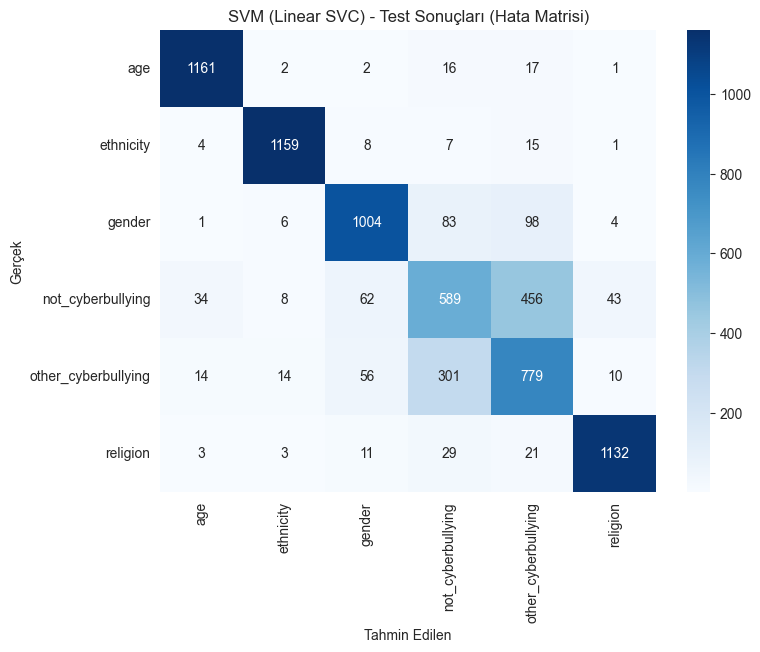




✅ İŞLEM TAMAMLANDI. Hangi model daha yüksek puan aldıysa onu not et.


In [ ]:
# --- Models 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("70-15-15 SPLIT AND DUAL MODEL TESTING IS STARTING....")


X = df['cleaned_text']
y = df['cyberbullying_type']

# 2. split (70 Train - 15 Val - 15 Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"📦 data distribution: Train={len(X_train)} | Val={len(X_val)} | Test={len(X_test)}")

# 3. vektorization

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))


X_train_vec = tfidf.fit_transform(X_train)
X_val_vec = tfidf.transform(X_val)
X_test_vec = tfidf.transform(X_test)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM (Linear SVC)": LinearSVC(random_state=42, dual='auto')
}


print("\n THE RACE HAS BEGUN! Both models are entering the test...\n")

for name, model in models.items():
    print("="*60)
    print(f"🤖 MODEL: {name}")
    print("="*60)
    
    # A. train
    model.fit(X_train_vec, y_train)
    
    # B. validation 
    val_acc = accuracy_score(y_val, model.predict(X_val_vec))
    print(f"   🔹 Validation result: %{val_acc*100:.2f}")

    # C. TEST 
    test_pred = model.predict(X_test_vec)
    test_acc = accuracy_score(y_test, test_pred)
    
    print(f"   🏆 TEST result: %{test_acc*100:.2f}")
    print("-" * 30)
    
    # D. report
    print(f"\n📄 {name} classification report:\n")
    print(classification_report(y_test, test_pred))
    
    # E. graph
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, test_pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f'{name} - test result confision matrix')
    plt.xlabel('prediction')
    plt.ylabel('reel')
    plt.show()
    print("\n\n") # Grafikler karışmasın diye boşluk

print("✅ completed.")

🚀 GELİŞMİŞ DISTILBERT EĞİTİMİ BAŞLIYOR (Analiz Modu)...
⚙️  Donanım: cuda
   -> Kart: NVIDIA GeForce RTX 4050 Laptop GPU

📥 Veri Yükleniyor...
📦 Sınıflar (6 adet): ['age', 'ethnicity', 'gender', 'not_cyberbullying', 'other_cyberbullying', 'religion']

📊 Sınıf Dağılımı (Dengesizlik var mı?):
cyberbullying_type
religion               7998
age                    7992
ethnicity              7960
gender                 7954
not_cyberbullying      7857
other_cyberbullying    7661
Name: count, dtype: int64

✂️  Veri Bölündü: Train=33195, Val=7113, Test=7114
⏳ Tokenizer Çalışıyor...
📥 Model İndiriliyor...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🔥 EĞİTİM BAŞLIYOR (3 Tur Döndürülecek)...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.352200,0.375460,0.846619,0.841156
2,0.268300,0.361302,0.863489,0.861634
3,0.217400,0.433024,0.860537,0.859912



🧪 FİNAL TEST YAPILIYOR (Görmediği %15 Veriyle)...



📄 DETAYLI SINIFLANDIRMA RAPORU:
                     precision    recall  f1-score   support

                age       0.97      0.98      0.97      1199
          ethnicity       0.98      0.99      0.98      1194
             gender       0.89      0.90      0.90      1193
  not_cyberbullying       0.69      0.59      0.63      1179
other_cyberbullying       0.68      0.76      0.72      1149
           religion       0.96      0.96      0.96      1200

           accuracy                           0.86      7114
          macro avg       0.86      0.86      0.86      7114
       weighted avg       0.86      0.86      0.86      7114



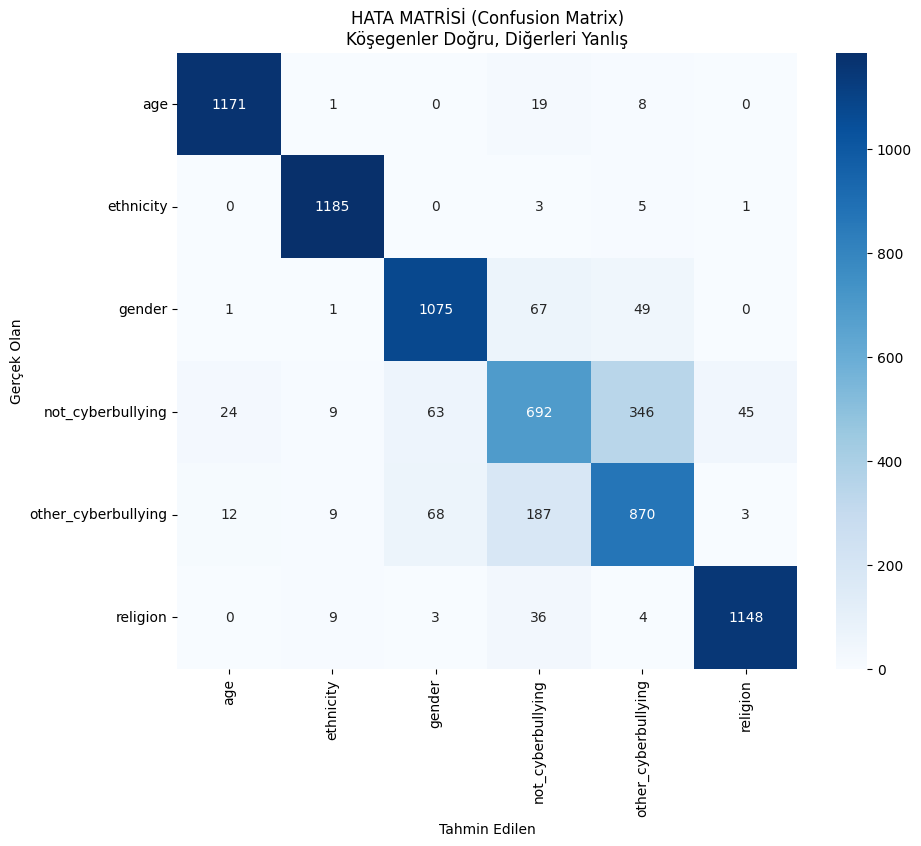


💾 Model './final_cyberbullying_model_v3' klasörüne kaydedildi.


In [ ]:
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments, DistilBertConfig
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from torch.utils.data import Dataset
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("🚀 ADVANCED DISTILBERT TRAINING BEGINS (Analysis Mode)...")

# 1. GPU KONTROLÜ
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚙️  hardware: {device}")
if device.type == 'cuda':
    print(f"   -> gpu: {torch.cuda.get_device_name(0)}")


def clean_text_for_bert(text):
    if text is None: return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r"[^a-z0-9\s.,!?']", '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


print("\n📥 data loading...")
df = pd.read_csv('cyberbullying_tweets.csv')
col_name = 'tweet_text' if 'tweet_text' in df.columns else 'text'

# claning
df['clean_text'] = df[col_name].apply(clean_text_for_bert)
df = df.dropna(subset=['clean_text'])
df = df[df['clean_text'] != ""]

# (Label Mapping)
unique_labels = sorted(df['cyberbullying_type'].unique())
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for i, label in enumerate(unique_labels)}

print(f"📦 classes ({len(unique_labels)} piece): {unique_labels}")
df['label_id'] = df['cyberbullying_type'].map(label2id)


print("\n📊 class distribution:")
print(df['cyberbullying_type'].value_counts())


train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['clean_text'].tolist(), 
    df['label_id'].tolist(), 
    test_size=0.30, 
    random_state=42, 
    stratify=df['label_id'].tolist()
)
# %30 Temp -> %15 Val, %15 Test
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, 
    temp_labels, 
    test_size=0.50, 
    random_state=42, 
    stratify=temp_labels
)

print(f"\n✂️  splitted: Train={len(train_labels)}, Val={len(val_labels)}, Test={len(test_labels)}")


print("⏳ Tokenizer is working....")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class CyberBullyingDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self): return len(self.labels)

train_dataset = CyberBullyingDataset(train_texts, train_labels, tokenizer)
val_dataset = CyberBullyingDataset(val_texts, val_labels, tokenizer)
test_dataset = CyberBullyingDataset(test_texts, test_labels, tokenizer)


print("📥 Model downloading...")
config = DistilBertConfig.from_pretrained(
    'distilbert-base-uncased', 
    num_labels=len(unique_labels),
    id2label=id2label,
    label2id=label2id
)
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', config=config)
model.to(device)


def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted') 
    return {'accuracy': acc, 'f1': f1}


training_args = TrainingArguments(
    output_dir='./results_final',
    num_train_epochs=3,              
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=True,                       
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)


print("\n🔥 train started ...")
trainer.train()



preds_output = trainer.predict(test_dataset)
y_preds = np.argmax(preds_output.predictions, axis=1)
y_true = test_labels


print("\n📄 classification report:")
print(classification_report(y_true, y_preds, target_names=unique_labels))


plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('(Confusion Matrix)')
plt.xlabel('predicted')
plt.ylabel('reel')
plt.show()


save_path = "./final_cyberbullying_model_v3"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)e
print(f"\n💾 Model '{save_path}' saved.")